# TP2 — Detector de máximo enfoque

**Integrantes:**
- Julián Barceló
- Jonatan Mild
- Víctor Hugo Astorga
- Roberto Manuel Briend
- Valentín Torres

**Materia:** Visión por Computadora I

**Video analizado:** `focus_video.mov`

---

### Objetivo

Implementar un detector de máximo enfoque sobre un video aplicando análisis espectral, de forma
análoga a lo que hacen las cámaras digitales para decidir cuándo una escena está enfocada. Para
eso se implementa la métrica **FM (Frequency Domain Image Blur Measure)** propuesta en el paper
*"Image Sharpness Measure for Blurred Images in Frequency Domain"* (De, K. & Masilamani, V.) y se
la evalúa midiendo sobre distintas regiones del frame.

**Referencias:**
- Paper: `Articulos/ImageSharpnessMeasureforBlurredImagesinFrequency.pdf`
- Fourier: `Codigo/Clase3/03.Fourier.ipynb`
- Consigna: `Diapositivas/Clase3.pdf` (páginas 19-20)


## Consigna

1. Implementar la métrica FM del paper para una imagen o región.
2. Realizar dos experimentos:
   - **2.1** Medición sobre todo el frame.
   - **2.2** Medición sobre una ROI central (5% o 10% del área).
3. Para cada experimento: **curva FM frame a frame** con el máximo enfoque marcado.
4. Detección automática de los puntos de máximo enfoque.
5. Matriz de enfoque superpuesta a un frame.
6. **Extra:** unsharp masking para expandir la zona de enfoque y devolverla.

Además de los puntos pedidos se agregaron los siguientes **extras**:

- Detección automática de la **región** de máximo enfoque (inicio, pico y fin), y no solo del
  frame puntual de FM máximo.
- Una **variante alternativa** del reenfoque por unsharp masking, aplicada únicamente sobre la
  banda de transición enfocado/desenfocado.
- Comparación contra una **métrica de enfoque alternativa** (*Gradient Energy*).
- Generación de **videos anotados** (carpeta `outs/`) que marcan frame a frame si la escena está
  enfocada o no, según la región detectada automáticamente.


## Configuración

In [1]:
%matplotlib inline

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter

VIDEO_PATH = Path('focus_video.mov')
OUTPUT_DIR = Path('outs')             # videos generados por el notebook
OUTPUT_DIR.mkdir(exist_ok=True)

ROI_AREA_FRACTIONS = (0.05, 0.10)     # consigna: 5% o 10% del área del frame
ROI_AREA_FRACTION = 0.10              # ROI de referencia para el análisis principal
THRESHOLD_DIVISOR = 1000              # umbral = max(AF) / 1000 (paper)
UNSHARP_K = 1.5
UNSHARP_BAND = (0.15, 0.25)           # banda bajo el máximo de la ROI para aplicar unsharp
FOCUS_MATRIX_GRID = (8, 8)
REGION_TOLERANCE = 0.10               # caída admitida respecto del pico (10%)

print('Config OK | ROI principal =', f'{ROI_AREA_FRACTION:.0%}')

Config OK | ROI principal = 10%


## Punto 1 — Métrica FM del paper

El paper mide el enfoque a partir del contenido espectral de la imagen: una imagen enfocada tiene
energía repartida en un rango de frecuencias mucho más amplio (hay más altas frecuencias, que son
las que forman bordes y texturas), mientras que en una imagen desenfocada esa energía se concentra
cerca del origen del espectro.

Dada una imagen en escala de grises $I$ de tamaño $M \times N$, el algoritmo del paper es:

1. **Step 1:** $F = \mathrm{FFT2}(I)$ — transformada de Fourier de la imagen.
2. **Step 2:** $F_c = \mathrm{fftshift}(F)$ — se corre el origen del espectro al centro.
3. **Step 3:** $AF = |F_c|$ — módulo del espectro centrado.
4. **Step 4:** $M_{max} = \max(AF)$ — máxima componente espectral.
5. **Step 5:** $TH$ = cantidad de píxeles de $AF$ cuyo valor supera el umbral $M_{max}/1000$.
6. **Step 6:** $FM = TH / (M \cdot N)$.

A mayor `FM`, mayor cantidad de componentes espectrales significativas presentes ⇒ imagen más
enfocada.


In [2]:
def to_grayscale(image: np.ndarray) -> np.ndarray:
    if image.ndim == 2:
        return image
    if image.ndim == 3 and image.shape[2] == 3:
        return cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    raise ValueError(f'Formato no soportado: {image.shape}')


def calc_fm(image: np.ndarray, threshold_divisor: int = THRESHOLD_DIVISOR) -> float:
    """Métrica FM del paper (De y Masilamani, 2013)."""
    gray = to_grayscale(image).astype(np.float32)
    magnitude = np.abs(np.fft.fftshift(np.fft.fft2(gray)))   # steps 1 a 3
    threshold = np.max(magnitude) / threshold_divisor        # steps 4 y 5
    return np.sum(magnitude > threshold) / magnitude.size    # step 6


def load_video(video_path: Path) -> tuple[list[np.ndarray], float]:
    """Devuelve todos los frames del video junto con sus FPS."""
    capture = cv.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise FileNotFoundError(f'No se pudo abrir: {video_path}')
    fps = capture.get(cv.CAP_PROP_FPS) or 30.0
    frames = []
    while True:
        ret, frame = capture.read()
        if not ret:
            break
        frames.append(frame)
    capture.release()
    return frames, fps

In [3]:
# Demo punto 1: carga del video y FM sobre el primer frame
frames, video_fps = load_video(VIDEO_PATH)
frame_indices = np.arange(len(frames))
video_alto, video_ancho = frames[0].shape[:2]

print(f'Video cargado: {len(frames)} frames | resolución {video_ancho}x{video_alto} | {video_fps:.2f} FPS')
print(f'FM frame 0 (completo): {calc_fm(frames[0]):.6f}')

Video cargado: 171 frames | resolución 640x360 | 29.97 FPS
FM frame 0 (completo): 0.007122


## Utilidades compartidas

In [4]:
def center_roi_bbox(image: np.ndarray, area_fraction: float = ROI_AREA_FRACTION):
    """Bounding box (x0, y0, x1, y1) de la ROI central.

    La consigna define la ROI por su *área* (5% o 10% del frame). Como la ROI es un
    rectángulo centrado y semejante al frame, para que su área sea una fracción `a` del
    total cada lado debe medir sqrt(a) del lado original.
    """
    h, w = image.shape[:2]
    side_fraction = float(np.sqrt(area_fraction))
    roi_h, roi_w = int(h * side_fraction), int(w * side_fraction)
    y0, x0 = (h - roi_h) // 2, (w - roi_w) // 2
    return x0, y0, x0 + roi_w, y0 + roi_h


def extract_center_roi(image: np.ndarray, area_fraction: float = ROI_AREA_FRACTION) -> np.ndarray:
    x0, y0, x1, y1 = center_roi_bbox(image, area_fraction)
    return image[y0:y1, x0:x1]


def draw_bbox(image: np.ndarray, bbox, color=(0, 255, 0), thickness: int = 2) -> np.ndarray:
    out = image.copy()
    cv.rectangle(out, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, thickness)
    return out


def compute_fm_series(regions: list[np.ndarray]) -> np.ndarray:
    return np.array([calc_fm(r) for r in regions], dtype=np.float32)


def detect_max_focus(fm_series: np.ndarray) -> int:
    """Punto 4: detección automática del frame de máximo enfoque."""
    return int(np.argmax(fm_series))


def plot_fm_curve(x, fm, max_idx, title, extra_series=None, extra_label=None, ax=None):
    """Curva FM frame a frame con el máximo enfoque marcado."""
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, fm, marker='o', markersize=3, label='FM')
    if extra_series is not None:
        ax.plot(x, extra_series, color='red', linewidth=1.5, label=extra_label)
    ax.axvline(max_idx, color='red', linestyle='--', label=f'Máx. detectado: frame {max_idx}')
    ax.set_title(title)
    ax.set_xlabel('Frame')
    ax.set_ylabel('FM')
    ax.legend()
    ax.grid(alpha=0.3)
    return ax

In [5]:
# Regiones para los experimentos: frame completo y ROIs centradas del 5% y 10%
roi_frames = {area: [extract_center_roi(f, area) for f in frames] for area in ROI_AREA_FRACTIONS}
roi_bboxes = {area: center_roi_bbox(frames[0], area) for area in ROI_AREA_FRACTIONS}

for area, bbox in roi_bboxes.items():
    ancho_roi, alto_roi = bbox[2] - bbox[0], bbox[3] - bbox[1]
    area_real = (ancho_roi * alto_roi) / (video_ancho * video_alto)
    print(f'ROI {area:.0%}: {ancho_roi}x{alto_roi} px | área real = {area_real:.2%}')

ROI 5%: 143x80 px | área real = 4.97%
ROI 10%: 202x113 px | área real = 9.91%


## Punto 2.1 — Experimento: medición sobre todo el frame

Se calcula FM para cada frame completo del video.

In [6]:
fm_full = compute_fm_series(frames)
max_idx_full = detect_max_focus(fm_full)

print(f'FM min={fm_full.min():.6f} | max={fm_full.max():.6f}')
print(f'Máximo enfoque detectado automáticamente -> frame {max_idx_full} | FM={fm_full[max_idx_full]:.6f}')

FM min=0.006819 | max=0.028624
Máximo enfoque detectado automáticamente -> frame 109 | FM=0.028624


## Punto 2.2 — Experimento: medición sobre ROI central

Se repite la medición pero solo sobre la región central del frame. La consigna habilita usar el
5% o el 10% del área, así que se calculan las dos para poder compararlas.

In [7]:
fm_roi = {}
for area in ROI_AREA_FRACTIONS:
    fm_roi[area] = compute_fm_series(roi_frames[area])
    idx = detect_max_focus(fm_roi[area])
    print(f'ROI {area:.0%} | FM min={fm_roi[area].min():.6f} | max={fm_roi[area].max():.6f} '
          f'-> máximo en frame {idx}')

# ROI de referencia para el resto del análisis
fm_roi_main = fm_roi[ROI_AREA_FRACTION]
max_idx_roi = detect_max_focus(fm_roi_main)

ROI 5% | FM min=0.054808 | max=0.465909 -> máximo en frame 111


ROI 10% | FM min=0.043766 | max=0.357706 -> máximo en frame 111


## Punto 3 — Curvas FM frame a frame

Para **cada experimento** se grafica la evolución de FM a lo largo del video. La línea vertical
roja marca el frame donde el algoritmo detectó el **máximo enfoque**.

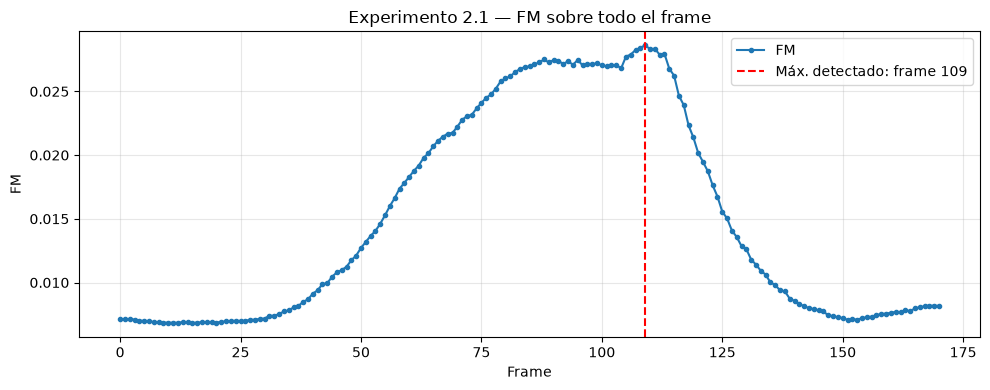

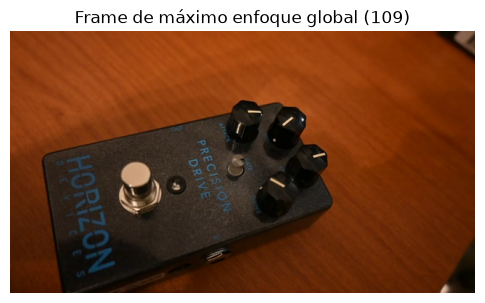

In [8]:
# Experimento 2.1: curva sobre todo el frame
plot_fm_curve(frame_indices, fm_full, max_idx_full, 'Experimento 2.1 — FM sobre todo el frame')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.imshow(cv.cvtColor(frames[max_idx_full], cv.COLOR_BGR2RGB))
plt.title(f'Frame de máximo enfoque global ({max_idx_full})')
plt.axis('off')
plt.show()

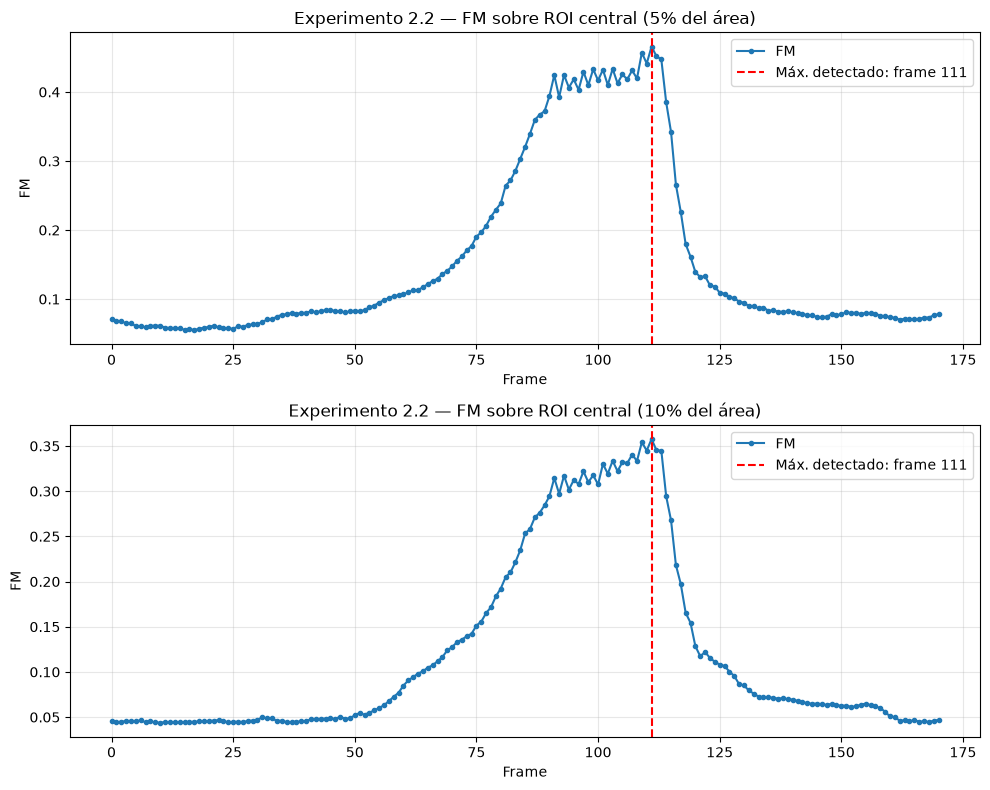

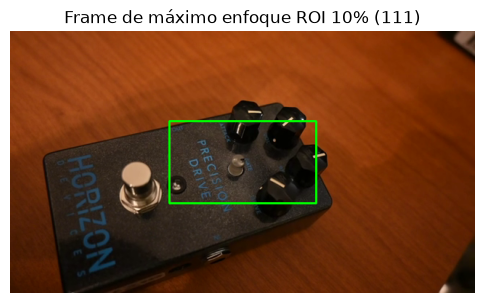

In [9]:
# Experimento 2.2: curvas sobre las ROIs centradas
fig, axes = plt.subplots(len(ROI_AREA_FRACTIONS), 1, figsize=(10, 4 * len(ROI_AREA_FRACTIONS)))
for ax, area in zip(axes, ROI_AREA_FRACTIONS):
    plot_fm_curve(frame_indices, fm_roi[area], detect_max_focus(fm_roi[area]),
                  f'Experimento 2.2 — FM sobre ROI central ({area:.0%} del área)', ax=ax)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.imshow(cv.cvtColor(draw_bbox(frames[max_idx_roi], roi_bboxes[ROI_AREA_FRACTION]), cv.COLOR_BGR2RGB))
plt.title(f'Frame de máximo enfoque ROI {ROI_AREA_FRACTION:.0%} ({max_idx_roi})')
plt.axis('off')
plt.show()

**Observación:** al concentrar la medición en el centro de la imagen —donde está el objeto de
interés— la métrica se vuelve mucho más sensible: los valores de FM son un orden de magnitud
mayores y el contraste entre enfocado y desenfocado es más marcado que midiendo sobre el frame
completo, donde el fondo (que nunca cambia de enfoque) diluye la señal.

## Punto 4 — Detección automática

Ambos experimentos usan `detect_max_focus()` (`argmax` de la serie FM), sin intervención manual.

In [10]:
deteccion = {
    'frame_completo': {'frame': max_idx_full, 'fm': float(fm_full[max_idx_full])},
    'roi_5pct': {'frame': detect_max_focus(fm_roi[0.05]), 'fm': float(fm_roi[0.05].max())},
    'roi_10pct': {'frame': detect_max_focus(fm_roi[0.10]), 'fm': float(fm_roi[0.10].max())},
}

for nombre, info in deteccion.items():
    print(f'{nombre:20s} -> frame {info["frame"]:3d} | FM = {info["fm"]:.6f}')

frame_completo       -> frame 109 | FM = 0.028624
roi_5pct             -> frame 111 | FM = 0.465909
roi_10pct            -> frame 111 | FM = 0.357706


### Punto 4 (extra) — De un punto de máximo enfoque a una *región* de máximo enfoque

El `argmax` devuelve un único frame, pero en la práctica el enfoque no se sostiene en un instante
aislado: hay una **región** de varios frames en los que la escena se ve nítida. Detectar esa
región es más útil (y más parecido a lo que hace el autofoco de una cámara) que quedarse con un
solo frame, que además es sensible al ruido de la métrica.

**Estrategia:**

1. Suavizar la curva de FM con un filtro de **Savitzky-Golay** (`scipy.signal.savgol_filter`) para
   atenuar el ruido frame a frame sin desplazar la ubicación del pico.
2. Ubicar el **pico** de la curva suavizada (`argmax`).
3. Definir un **umbral relativo** al pico: `umbral = pico * (1 - tolerancia)`, con
   `tolerancia = 0.10` (se admite hasta un 10% de caída respecto del máximo).
4. Expandir hacia atrás y hacia adelante desde el pico mientras la curva suavizada se mantenga por
   encima del umbral, obteniendo el **frame de inicio** y el **frame de fin** de la región.

El criterio es totalmente automático, robusto al ruido gracias al suavizado, y devuelve los tres
valores que interesan: inicio, pico y fin.

In [11]:
def detect_focus_region(fm_series, tolerance: float = REGION_TOLERANCE,
                        window: int = 11, polyorder: int = 2) -> dict:
    """Detecta automáticamente la región de máximo enfoque a partir de una curva de FM.

    Devuelve un dict con la curva suavizada, el pico (índice y valor), el umbral usado y
    los frames de inicio y fin de la región.
    """
    fm = np.asarray(fm_series, dtype=float)
    n = len(fm)

    # ventana del filtro: impar y no mayor a la cantidad de muestras
    w = min(window, n if n % 2 else n - 1)
    if w % 2 == 0:
        w -= 1
    fm_smooth = savgol_filter(fm, w, polyorder) if w >= polyorder + 2 else fm.copy()

    peak_idx = int(np.argmax(fm_smooth))
    peak_val = float(fm_smooth[peak_idx])
    threshold = peak_val * (1 - tolerance)

    start = peak_idx
    while start > 0 and fm_smooth[start - 1] >= threshold:
        start -= 1

    end = peak_idx
    while end < n - 1 and fm_smooth[end + 1] >= threshold:
        end += 1

    return {'fm_smooth': fm_smooth, 'peak_idx': peak_idx, 'peak_val': peak_val,
            'threshold': threshold, 'start': start, 'end': end}


def plot_focus_region(fm_series, region: dict, title: str, ax=None, label: str = 'FM'):
    """Grafica la curva (cruda y suavizada), la región detectada, el pico y el umbral."""
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    n = len(fm_series)
    ax.scatter(range(n), fm_series, s=10, alpha=0.4, label=f'{label} (original)')
    ax.plot(region['fm_smooth'], color='tab:orange', lw=2, label=f'{label} (suavizado)')
    ax.axvspan(region['start'], region['end'], color='green', alpha=0.15,
               label=f"Región [{region['start']}, {region['end']}]")
    ax.axvline(region['peak_idx'], color='red', linestyle='--', lw=1.5,
               label=f"Pico (frame {region['peak_idx']})")
    ax.axhline(region['threshold'], color='gray', linestyle=':', lw=1, label='Umbral')
    ax.set_title(title)
    ax.set_xlabel('Frame')
    ax.set_ylabel(label)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)
    return ax

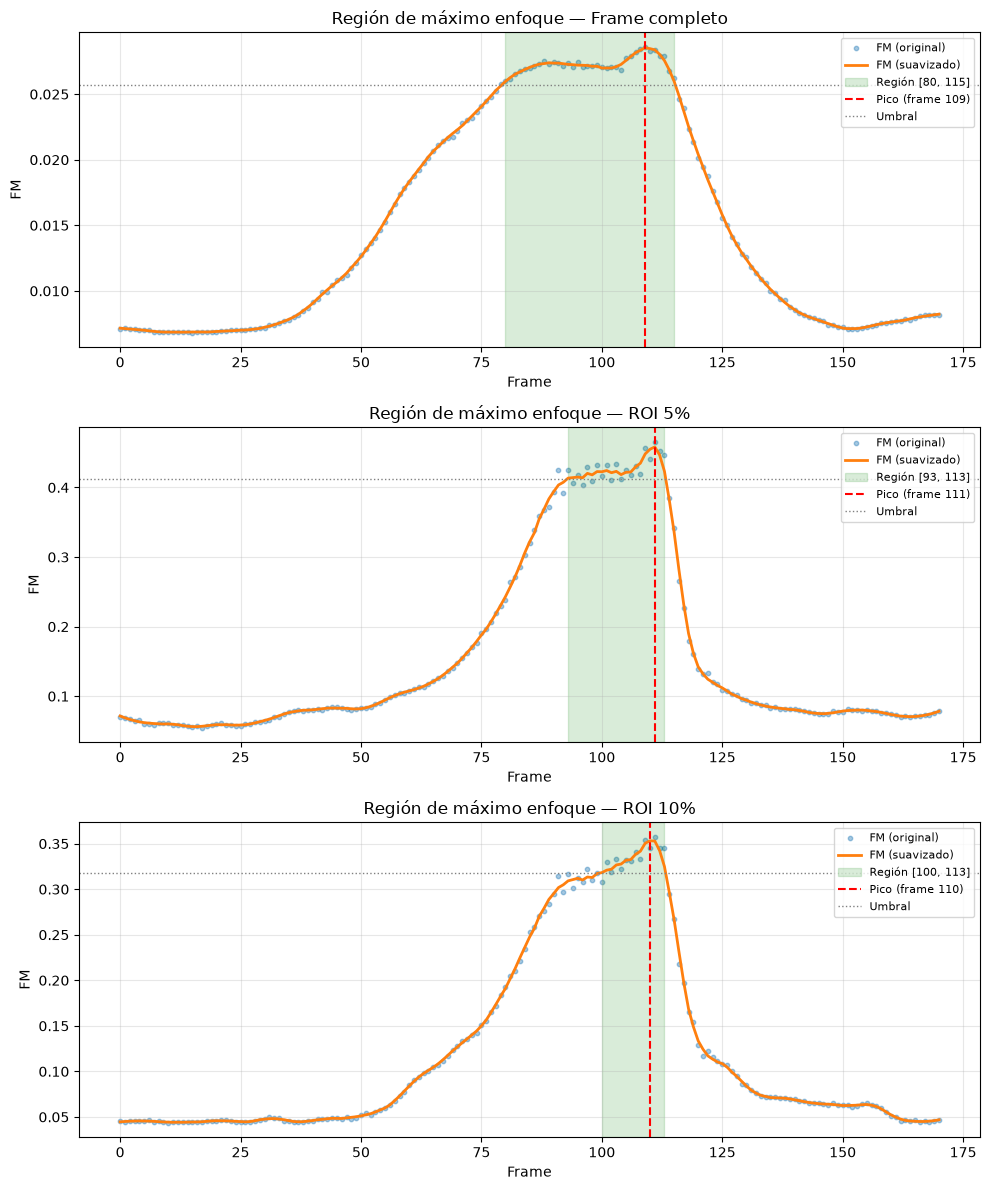

Experimento       Inicio    Pico     Fin  Duración
Frame completo        80     109     115        36
ROI 5%                93     111     113        21
ROI 10%              100     110     113        14


In [12]:
series_por_experimento = {
    'Frame completo': fm_full,
    'ROI 5%': fm_roi[0.05],
    'ROI 10%': fm_roi[0.10],
}
regiones = {nombre: detect_focus_region(serie) for nombre, serie in series_por_experimento.items()}

fig, axes = plt.subplots(len(regiones), 1, figsize=(10, 4 * len(regiones)))
for ax, (nombre, region) in zip(axes, regiones.items()):
    plot_focus_region(series_por_experimento[nombre], region,
                      f'Región de máximo enfoque — {nombre}', ax=ax)
plt.tight_layout()
plt.show()

print(f"{'Experimento':<16}{'Inicio':>8}{'Pico':>8}{'Fin':>8}{'Duración':>10}")
for nombre, r in regiones.items():
    print(f"{nombre:<16}{r['start']:>8}{r['peak_idx']:>8}{r['end']:>8}{r['end'] - r['start'] + 1:>10}")

**Observación:** las tres regiones se solapan y sus picos caen prácticamente en el mismo frame,
lo cual indica que tanto la métrica como el criterio de detección son consistentes frente a la
forma de la región analizada. Donde sí hay diferencias es en el **ancho**: medir sobre el frame
completo da la región más ancha (36 frames), porque el fondo aporta un piso de altas frecuencias
que nunca cambia y amortigua la caída relativa de FM alrededor del pico. Las ROIs, que solo ven el
objeto de interés, dan regiones bastante más angostas y por lo tanto una estimación más exigente
de "en foco". Entre las dos, la del 10% es la más angosta (14 frames): la del 5% tiene cuatro veces
menos píxeles, su curva es más ruidosa y el suavizado la ensancha un poco (21 frames).

## Punto 5 — Matriz de enfoque superpuesta

Se divide el frame de máximo enfoque en una grilla de celdas y se calcula FM en cada una, para ver
cómo se distribuye espacialmente el enfoque dentro de una misma imagen.

In [13]:
def compute_focus_matrix(image: np.ndarray, grid_size: tuple[int, int] = FOCUS_MATRIX_GRID):
    """FM celda por celda sobre una grilla de filas x columnas."""
    gray = to_grayscale(image)
    rows, cols = grid_size
    h, w = gray.shape
    focus_map = np.zeros((rows, cols), dtype=np.float32)
    for r in range(rows):
        y0, y1 = r * h // rows, (r + 1) * h // rows
        for c in range(cols):
            x0, x1 = c * w // cols, (c + 1) * w // cols
            focus_map[r, c] = calc_fm(gray[y0:y1, x0:x1])
    return focus_map, gray


def overlay_focus_matrix(image_gray: np.ndarray, focus_map: np.ndarray) -> np.ndarray:
    heatmap = cv.resize(focus_map, (image_gray.shape[1], image_gray.shape[0]),
                        interpolation=cv.INTER_NEAREST)
    heatmap_norm = cv.normalize(heatmap, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
    heatmap_color = cv.applyColorMap(heatmap_norm, cv.COLORMAP_JET)
    base = cv.cvtColor(image_gray, cv.COLOR_GRAY2BGR)
    return cv.addWeighted(base, 0.55, heatmap_color, 0.45, 0)

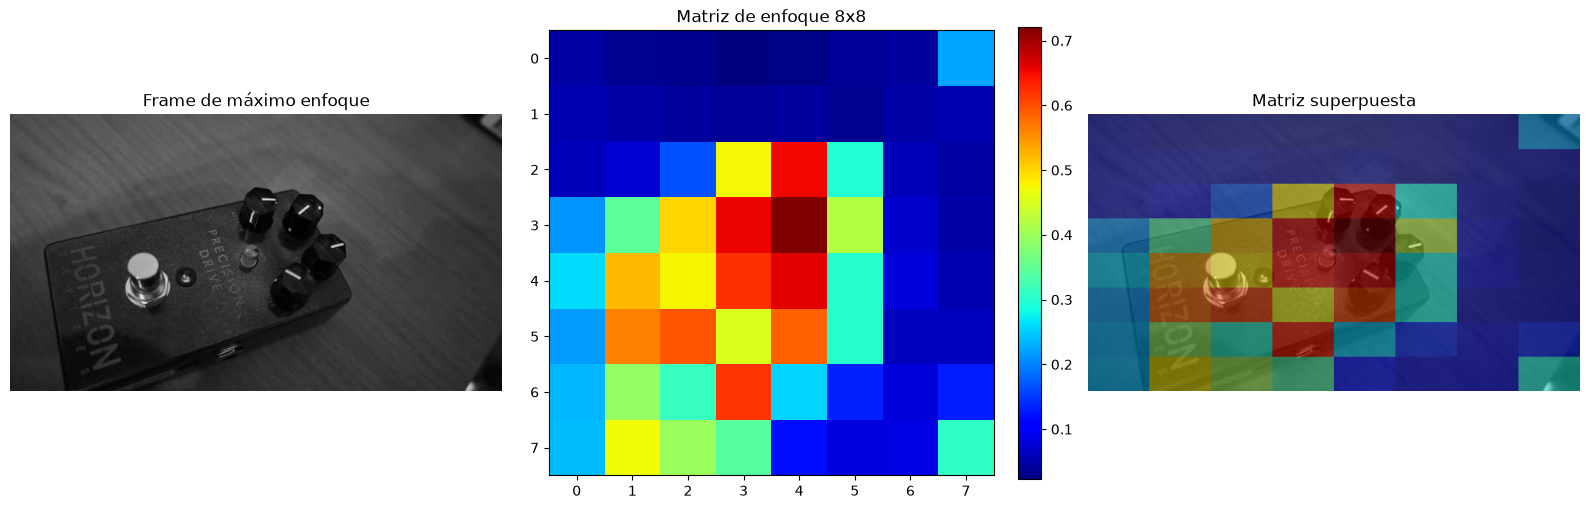

In [14]:
focus_map, gray_frame = compute_focus_matrix(frames[max_idx_full])
overlay = overlay_focus_matrix(gray_frame, focus_map)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(gray_frame, cmap='gray')
axes[0].set_title('Frame de máximo enfoque')
axes[0].axis('off')
im = axes[1].imshow(focus_map, cmap='jet')
axes[1].set_title(f'Matriz de enfoque {FOCUS_MATRIX_GRID[0]}x{FOCUS_MATRIX_GRID[1]}')
fig.colorbar(im, ax=axes[1], fraction=0.046)
axes[2].imshow(cv.cvtColor(overlay, cv.COLOR_BGR2RGB))
axes[2].set_title('Matriz superpuesta')
axes[2].axis('off')
plt.tight_layout()
plt.show()

### Punto 5 (extra) — Sensibilidad al tamaño de celda

Como se señala en *"Analysis of Focus Measure Operators"*, cualquier medida de enfoque es sensible
al tamaño de la ventana sobre la que se calcula: una celda muy chica contiene poco contenido
frecuencial y la métrica se vuelve ruidosa. Se repite la matriz de enfoque con tres tamaños de
grilla sobre el mismo frame para verificarlo.

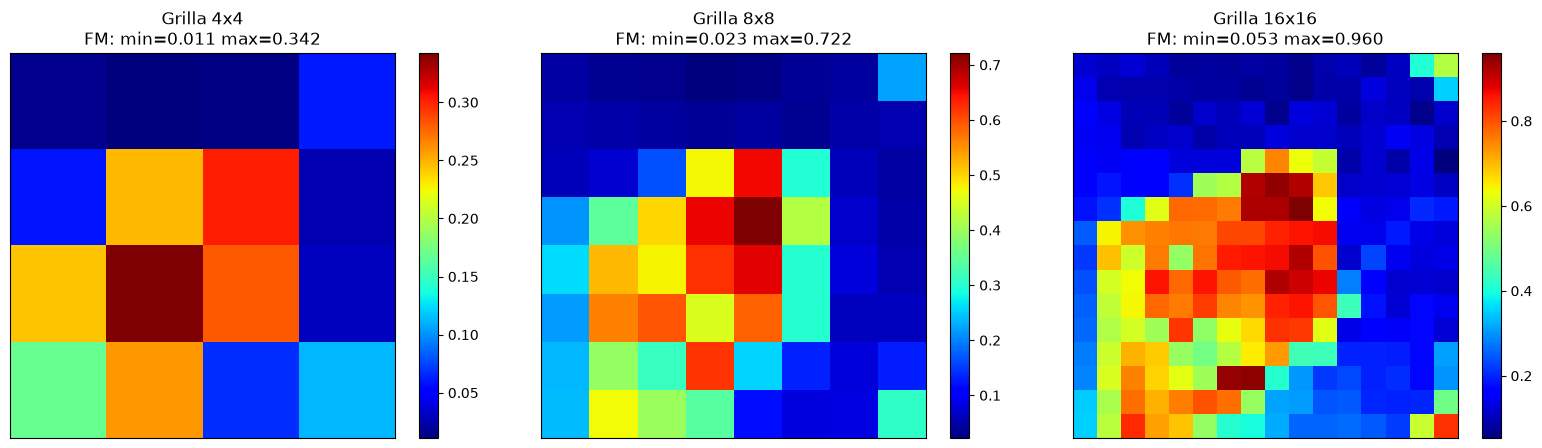

In [15]:
grillas = [(4, 4), (8, 8), (16, 16)]

fig, axes = plt.subplots(1, len(grillas), figsize=(16, 4.5))
for ax, grid in zip(axes, grillas):
    fmap, _ = compute_focus_matrix(frames[max_idx_full], grid)
    im = ax.imshow(fmap, cmap='jet')
    ax.set_title(f'Grilla {grid[0]}x{grid[1]}\nFM: min={fmap.min():.3f} max={fmap.max():.3f}')
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

**Observación:** el enfoque no es uniforme dentro de una misma imagen. Las celdas con más
textura y bordes (el objeto de interés) muestran FM local alto, mientras que las zonas lisas
—fondo, superficies planas— dan valores bajos aunque estén perfectamente enfocadas: donde no hay
detalle, no hay altas frecuencias que medir. Al achicar las celdas el rango de FM se dispara y el
mapa se vuelve más ruidoso, confirmando la dependencia del tamaño de ventana; con celdas más
grandes el mapa es más estable pero se pierde resolución espacial.

## Punto 6 (extra) — Unsharp masking

El unsharp masking realza las altas frecuencias restando a la imagen una versión suavizada de sí
misma. La idea de este punto es aplicarlo sobre los frames cercanos al máximo de enfoque para
**expandir la zona considerada enfocada** y **devolver** el rango de frames resultante.

In [16]:
def unsharp_masking(image: np.ndarray, k: float = UNSHARP_K) -> np.ndarray:
    blurred = cv.GaussianBlur(image, (7, 7), 0.5)
    return cv.addWeighted(image, k + 1.0, blurred, -k, 0)


def expand_focus_zone(
    roi_frames: list[np.ndarray],
    fm_roi: np.ndarray,
    max_idx_roi: int,
    unsharp_band: tuple[float, float] = UNSHARP_BAND,
    unsharp_k: float = UNSHARP_K,
) -> dict:
    """Aplica unsharp y devuelve la zona de enfoque expandida."""
    max_fm = float(fm_roi[max_idx_roi])
    lower_drop, upper_drop = unsharp_band
    fm_unsharp = []
    unsharp_applied = []
    started = passed_max = finished = False

    for roi, value in zip(roi_frames, fm_roi):
        drop = max_fm - value
        in_band = (drop >= max_fm * lower_drop) and (drop <= max_fm * upper_drop)
        if value == max_fm:
            passed_max = True
        use_unsharp = False
        if not started and not passed_max and in_band:
            started = use_unsharp = True
        elif started and not passed_max:
            use_unsharp = drop >= max_fm * lower_drop
        elif started and passed_max and not finished:
            if in_band:
                use_unsharp = True
            elif drop > max_fm * upper_drop:
                finished = True
        if use_unsharp:
            fm_unsharp.append(calc_fm(unsharp_masking(roi, unsharp_k)))
        else:
            fm_unsharp.append(float(value))
        unsharp_applied.append(use_unsharp)

    fm_unsharp = np.array(fm_unsharp, dtype=np.float32)
    unsharp_applied = np.array(unsharp_applied, dtype=bool)
    indices = np.arange(len(fm_roi))
    threshold = max_fm * (1 - lower_drop)
    before = indices[fm_roi >= threshold]
    after = indices[fm_unsharp >= threshold]
    expanded = indices[unsharp_applied]
    return {
        'fm_unsharp': fm_unsharp,
        'unsharp_applied': unsharp_applied,
        'focus_threshold': threshold,
        'focus_frames_before': before,
        'focus_frames_after': after,
        'expanded_focus_frames': expanded,
    }

In [17]:
extra = expand_focus_zone(roi_frames[ROI_AREA_FRACTION], fm_roi_main, max_idx_roi)
fm_roi_unsharp = extra['fm_unsharp']
expanded = extra['expanded_focus_frames']

print('=== Zona de enfoque expandida (devuelta) ===')
print(f'Umbral FM: {extra["focus_threshold"]:.6f}')
print(f'En foco ANTES:   {len(extra["focus_frames_before"])} frames -> {extra["focus_frames_before"].tolist()}')
print(f'En foco DESPUÉS: {len(extra["focus_frames_after"])} frames -> {extra["focus_frames_after"].tolist()}')
print(f'Unsharp aplicado: {len(expanded)} frames -> {expanded.tolist()}')
if len(expanded):
    print(f'Rango devuelto: frames {expanded[0]} a {expanded[-1]}')
print(f'Ganancia: {len(extra["focus_frames_after"]) - len(extra["focus_frames_before"])} frame(s)')

=== Zona de enfoque expandida (devuelta) ===
Umbral FM: 0.304050
En foco ANTES:   21 frames -> [91, 93, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113]
En foco DESPUÉS: 28 frames -> [87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114]
Unsharp aplicado: 7 frames -> [87, 88, 89, 90, 92, 94, 114]
Rango devuelto: frames 87 a 114
Ganancia: 7 frame(s)


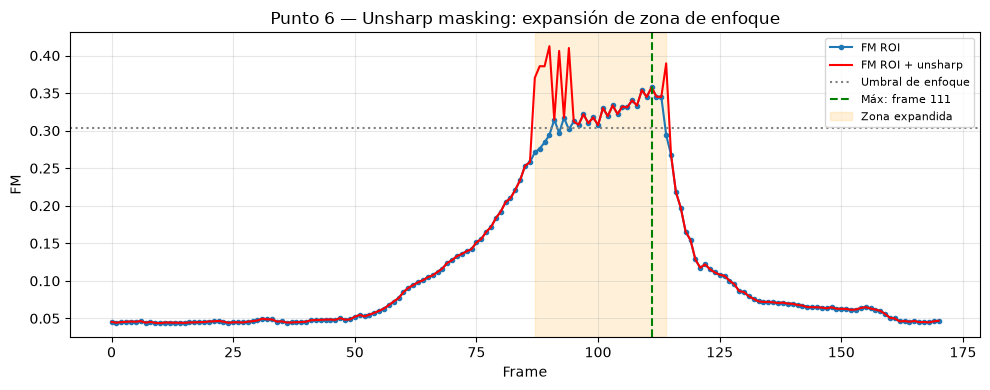

In [18]:
# Curva con la zona expandida marcada
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(frame_indices, fm_roi_main, marker='o', markersize=3, label='FM ROI')
ax.plot(frame_indices, fm_roi_unsharp, color='red', linewidth=1.5, label='FM ROI + unsharp')
ax.axhline(extra['focus_threshold'], color='gray', linestyle=':', label='Umbral de enfoque')
ax.axvline(max_idx_roi, color='green', linestyle='--', label=f'Máx: frame {max_idx_roi}')
if len(expanded):
    ax.axvspan(expanded[0], expanded[-1], color='orange', alpha=0.15, label='Zona expandida')
ax.set_title('Punto 6 — Unsharp masking: expansión de zona de enfoque')
ax.set_xlabel('Frame')
ax.set_ylabel('FM')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

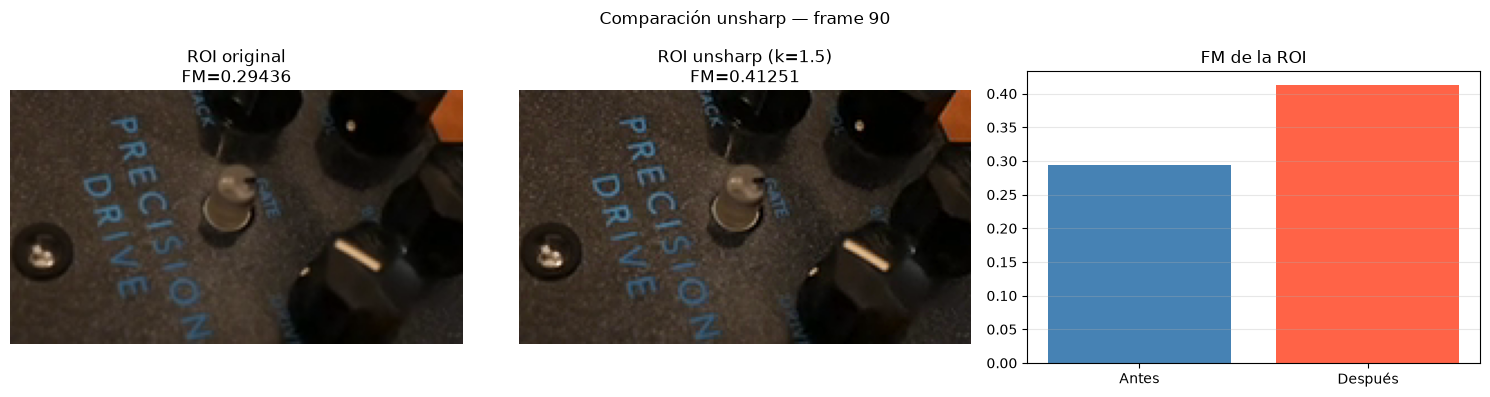

In [19]:
# Comparación visual: ROI original vs. ROI reenfocada
demo_idx = int(expanded[len(expanded) // 2]) if len(expanded) else max_idx_roi
roi_orig = roi_frames[ROI_AREA_FRACTION][demo_idx]
roi_sharp = unsharp_masking(roi_orig)
fm_b, fm_a = fm_roi_main[demo_idx], calc_fm(roi_sharp)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Comparación unsharp — frame {demo_idx}')
axes[0].imshow(cv.cvtColor(roi_orig, cv.COLOR_BGR2RGB))
axes[0].set_title(f'ROI original\nFM={fm_b:.5f}')
axes[0].axis('off')
axes[1].imshow(cv.cvtColor(roi_sharp, cv.COLOR_BGR2RGB))
axes[1].set_title(f'ROI unsharp (k={UNSHARP_K})\nFM={fm_a:.5f}')
axes[1].axis('off')
axes[2].bar(['Antes', 'Después'], [fm_b, fm_a], color=['steelblue', 'tomato'])
axes[2].set_title('FM de la ROI')
axes[2].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Punto 6 (extra) — Variante: unsharp masking sobre la banda de transición

La implementación anterior recorre la curva con una máquina de estados (empezó / pasó el máximo /
terminó) para decidir dónde aplicar el realce. Una forma alternativa de resolver lo mismo, más
directa, es trabajar con la **caída relativa** de cada frame respecto del pico y aplicar el realce
únicamente en la **banda de transición** entre enfocado y desenfocado:

- Sobre frames muy desenfocados **no** conviene aplicarlo: no hay altas frecuencias reales para
  recuperar, y la métrica sube de forma artificial sin que la imagen mejore.
- Sobre frames que ya están dentro de la región de enfoque tampoco aporta demasiado, porque ya
  están nítidos.

Por eso se realza solo el rango de frames cuya caída de FM respecto del pico está entre `pct_fin`
y `pct_ini`: ni encima del pico, ni demasiado lejos de él.

**Detalle importante:** una vez aplicado el realce, la región se vuelve a delimitar **anclada al
frame de pico original**, sin buscar un máximo nuevo. Si se dejara que el algoritmo busque el pico
de nuevo sobre la curva modificada, un frame de la banda de transición con el FM artificialmente
inflado podría superar al pico real y correr toda la región detectada hacia una zona que no
corresponde al enfoque genuino de la escena.

In [20]:
def apply_unsharp_on_transition(regions: list[np.ndarray], fm_series, region: dict,
                                band: tuple[float, float] = (0.05, 0.25), k: float = UNSHARP_K):
    """Recalcula FM aplicando unsharp masking solo en la banda de transición.

    `band` se expresa como caída relativa respecto del pico: se realzan los frames cuyo FM
    cayó entre band[0] y band[1] respecto del valor pico.
    """
    peak_val = region['peak_val']
    lower, upper = band
    fm_new, applied = [], []
    for image, value in zip(regions, fm_series):
        drop = (peak_val - float(value)) / peak_val if peak_val > 0 else 0.0
        in_band = lower <= drop <= upper
        fm_new.append(calc_fm(unsharp_masking(image, k)) if in_band else float(value))
        applied.append(in_band)
    return np.array(fm_new, dtype=np.float32), np.array(applied, dtype=bool)


def expand_region_from_peak(fm_series, peak_idx: int, peak_val: float,
                            tolerance: float = REGION_TOLERANCE) -> dict:
    """Re-delimita la región partiendo de un pico ya conocido, sin buscar uno nuevo."""
    fm = np.asarray(fm_series, dtype=float)
    threshold = peak_val * (1 - tolerance)

    start = peak_idx
    while start > 0 and fm[start - 1] >= threshold:
        start -= 1

    end = peak_idx
    while end < len(fm) - 1 and fm[end + 1] >= threshold:
        end += 1

    return {'peak_idx': peak_idx, 'peak_val': peak_val, 'threshold': threshold,
            'start': start, 'end': end}

In [21]:
# Se aplica sobre la ROI del 5%, que es donde el efecto se observa más claramente
area_transicion = 0.05
region_roi5 = regiones['ROI 5%']

fm_roi5_sharp, aplicados = apply_unsharp_on_transition(
    roi_frames[area_transicion], fm_roi[area_transicion], region_roi5, band=(0.05, 0.25), k=UNSHARP_K)

region_roi5_sharp = expand_region_from_peak(
    fm_roi5_sharp, region_roi5['peak_idx'], region_roi5['peak_val'], tolerance=REGION_TOLERANCE)

print(f'Unsharp aplicado en {aplicados.sum()} frames (banda de transición)')
print(f"Región de enfoque ORIGINAL (ROI 5%):         [{region_roi5['start']}, {region_roi5['end']}] "
      f"-> {region_roi5['end'] - region_roi5['start'] + 1} frames")
print(f"Región con UNSHARP en la transición:         [{region_roi5_sharp['start']}, {region_roi5_sharp['end']}] "
      f"-> {region_roi5_sharp['end'] - region_roi5_sharp['start'] + 1} frames")

Unsharp aplicado en 23 frames (banda de transición)
Región de enfoque ORIGINAL (ROI 5%):         [93, 113] -> 21 frames
Región con UNSHARP en la transición:         [87, 114] -> 28 frames


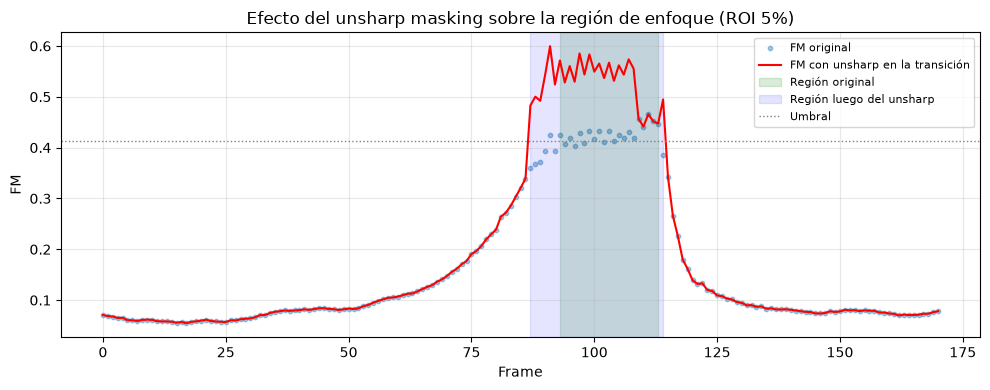

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(frame_indices, fm_roi[area_transicion], s=10, alpha=0.4, label='FM original')
ax.plot(fm_roi5_sharp, color='red', lw=1.5, label='FM con unsharp en la transición')
ax.axvspan(region_roi5['start'], region_roi5['end'], color='green', alpha=0.15, label='Región original')
ax.axvspan(region_roi5_sharp['start'], region_roi5_sharp['end'], color='blue', alpha=0.10,
           label='Región luego del unsharp')
ax.axhline(region_roi5_sharp['threshold'], color='gray', linestyle=':', lw=1, label='Umbral')
ax.set_title('Efecto del unsharp masking sobre la región de enfoque (ROI 5%)')
ax.set_xlabel('Frame')
ax.set_ylabel('FM')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Punto 7 (extra) — Comparación con una métrica de enfoque alternativa

Como validación cruzada se compara la métrica `FM` del paper —que trabaja en el dominio
frecuencial— contra una métrica clásica que trabaja en el dominio espacial: la **energía del
gradiente** (suma de los cuadrados de las derivadas de Sobel en X e Y). Una imagen enfocada tiene
bordes más marcados y, por lo tanto, mayor energía de gradiente.

Si dos métricas construidas sobre principios distintos detectan la misma región, es una buena
señal de que esa región corresponde efectivamente al momento en que la escena está en foco y no a
un artefacto de una única métrica.

In [23]:
def gradient_energy(image: np.ndarray) -> float:
    """Métrica de enfoque alternativa: energía del gradiente (Sobel en X e Y)."""
    gray = to_grayscale(image)
    gx = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
    gy = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)
    return float(np.sum(gx ** 2 + gy ** 2))

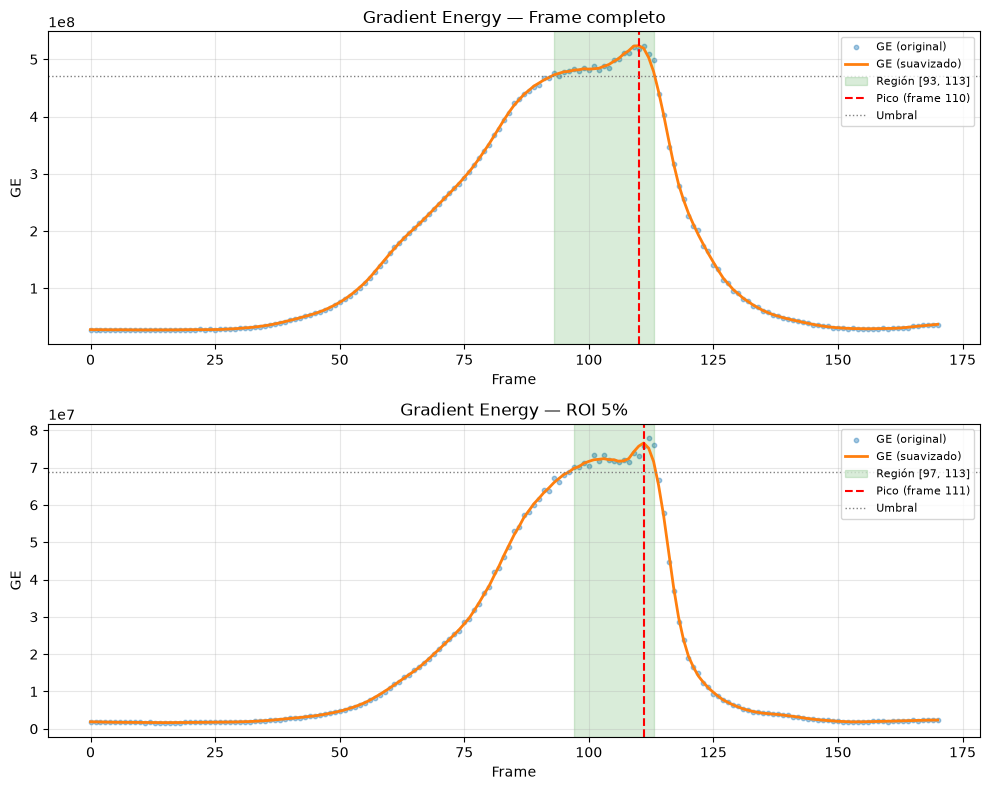

Métrica / región              Inicio    Pico     Fin
FM — frame completo               80     109     115
Gradient Energy — completo        93     110     113
FM — ROI 5%                       93     111     113
Gradient Energy — ROI 5%          97     111     113


In [24]:
ge_full = np.array([gradient_energy(f) for f in frames])
ge_roi5 = np.array([gradient_energy(r) for r in roi_frames[0.05]])

region_ge_full = detect_focus_region(ge_full)
region_ge_roi5 = detect_focus_region(ge_roi5)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_focus_region(ge_full, region_ge_full, 'Gradient Energy — Frame completo', ax=axes[0], label='GE')
plot_focus_region(ge_roi5, region_ge_roi5, 'Gradient Energy — ROI 5%', ax=axes[1], label='GE')
plt.tight_layout()
plt.show()

print(f"{'Métrica / región':<28}{'Inicio':>8}{'Pico':>8}{'Fin':>8}")
for nombre, r in [('FM — frame completo', regiones['Frame completo']),
                  ('Gradient Energy — completo', region_ge_full),
                  ('FM — ROI 5%', regiones['ROI 5%']),
                  ('Gradient Energy — ROI 5%', region_ge_roi5)]:
    print(f"{nombre:<28}{r['start']:>8}{r['peak_idx']:>8}{r['end']:>8}")

## Punto 8 (extra) — Videos anotados

Como entregable adicional se genera un video en el que cada frame se marca en **verde** si
pertenece a la región de máximo enfoque detectada automáticamente, o en **rojo** si no. Sirve para
validar visualmente —reproduciendo el video— que la detección automática coincide con lo que se ve
a simple vista.

In [25]:
def build_annotated_video(frames: list[np.ndarray], region: dict, output_path: Path,
                         fps: float = 30.0, bbox=None,
                         color_ok=(0, 255, 0), color_ko=(0, 0, 255)) -> Path:
    """Anota cada frame como enfocado/desenfocado según la región detectada y guarda el video."""
    start, end = region['start'], region['end']
    alto, ancho = frames[0].shape[:2]

    fourcc = cv.VideoWriter_fourcc(*'mp4v')
    writer = cv.VideoWriter(str(output_path), fourcc, fps, (ancho, alto))

    for idx, frame in enumerate(frames):
        f = frame.copy()
        enfocado = start <= idx <= end
        color = color_ok if enfocado else color_ko
        if bbox is not None:
            cv.rectangle(f, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 3)
        else:
            cv.rectangle(f, (5, 5), (ancho - 5, alto - 5), color, 6)
        texto = 'ENFOCADO' if enfocado else 'DESENFOCADO'
        cv.putText(f, texto, (10, 30), cv.FONT_HERSHEY_SIMPLEX, 0.8, color, 2, cv.LINE_AA)
        writer.write(f)

    writer.release()
    print(f'Video generado: {output_path}')
    return output_path

In [26]:
# Video anotado con la detección sobre el frame completo
video_full = build_annotated_video(frames, regiones['Frame completo'],
                                   OUTPUT_DIR / 'focus_video_anotado_full.mp4', fps=video_fps)

# Video anotado con la detección sobre la ROI del 5%, marcando además el recuadro de la ROI
video_roi5 = build_annotated_video(frames, regiones['ROI 5%'],
                                   OUTPUT_DIR / 'focus_video_anotado_roi5.mp4', fps=video_fps,
                                   bbox=roi_bboxes[0.05])

Video generado: outs\focus_video_anotado_full.mp4
Video generado: outs\focus_video_anotado_roi5.mp4


Los dos videos quedan en la carpeta **`outs/`** del TP:

| Archivo | Qué muestra |
|---|---|
| `outs/focus_video_anotado_full.mp4` | Región detectada midiendo FM sobre el **frame completo**. El borde de la imagen se pinta de verde mientras el frame pertenece a la región de enfoque y de rojo fuera de ella. |
| `outs/focus_video_anotado_roi5.mp4` | Región detectada midiendo FM sobre la **ROI central del 5%**. Se dibuja además el recuadro de la ROI, que cambia de color según el frame esté dentro o fuera de la región. |

Al reproducirlos se ve que el cambio de rojo a verde ocurre justo cuando la escena empieza a verse
nítida, y el recuadro de la ROI (video `roi5`) se mantiene verde durante una ventana más corta y
mejor ajustada al momento de foco real que el borde del frame completo.

## Conclusiones

**Sobre la métrica del paper.** La métrica FM de De y Masilamani resultó simple de implementar y
efectiva: no necesita una imagen de referencia y se apoya en una idea muy directa, que una imagen
nítida reparte energía en muchas más frecuencias que una borrosa. Contar cuántas componentes del
espectro superan un umbral relativo al máximo (`max/1000`) alcanza para seguir el ciclo de enfoque
del video sin ningún ajuste manual. Sobre `focus_video.mov` (171 frames, 640x360) el FM del frame
completo se movió entre 0.0068 y 0.0286, un rango chico pero perfectamente monótono alrededor del
foco.

**Dónde se mide importa tanto como qué se mide.** Fue la diferencia más marcada entre los dos
experimentos. Sobre el frame completo el FM máximo fue 0.0286; sobre la ROI central del 10%, 0.358;
sobre la del 5%, 0.466 — más de un orden de magnitud. El motivo es que el fondo ocupa la mayor
parte del cuadro, nunca cambia de nitidez y actúa como un piso constante que diluye la señal. Al
recortar la ROI se mide únicamente el objeto que efectivamente entra y sale de foco, y la curva se
vuelve mucho más contrastada. También corrió el pico: frame 109 midiendo sobre todo el cuadro y 111
sobre cualquiera de las dos ROIs. La diferencia es de dos frames (menos de 0.07 s), pero muestra
que la elección de la región no es neutral.

**Del "frame de máximo enfoque" a la "región de enfoque".** El `argmax` de la serie de FM resuelve
el punto 4 de la consigna y es determinista, pero devuelve un único frame y es sensible al ruido de
la métrica. Nos pareció más representativo detectar además la región completa: suavizar la curva
con Savitzky-Golay, ubicar el pico y expandirse hacia ambos lados mientras la curva se mantenga
dentro del 10% del máximo. Con ese criterio las tres regiones detectadas se solapan y coinciden en
el pico, pero difieren en el ancho: 36 frames midiendo sobre el frame completo (80–115), 21 sobre
la ROI del 5% (93–113) y 14 sobre la del 10% (100–113). Que las tres apunten al mismo lugar es una
buena señal de robustez; que la más ancha sea la del frame completo confirma lo del punto anterior,
el fondo suaviza la caída de FM y hace parecer enfocados frames que no lo están tanto.

**El enfoque no es uniforme dentro de una imagen.** La matriz de enfoque lo dejó claro: sobre el
frame de máximo enfoque global, las celdas con textura y bordes dan FM local alto y las zonas lisas
dan valores bajos, aunque estén igual de enfocadas. Donde no hay detalle, no hay altas frecuencias
que medir. Al variar el tamaño de grilla (4x4, 8x8, 16x16) apareció el otro efecto conocido y
reportado en la literatura sobre operadores de enfoque: con celdas chicas el rango de FM se dispara
y el mapa se vuelve ruidoso, porque cada celda tiene muy poco contenido frecuencial; con celdas
grandes el mapa es más estable pero se pierde resolución espacial. Es un compromiso que hay que
elegir según para qué se use el mapa.

**Unsharp masking: sirve, pero hay que aplicarlo con criterio.** Realzando las altas frecuencias de
los frames cercanos al máximo se logró ampliar la zona considerada enfocada de 21 a 28 frames sobre
la ROI del 10% (una ganancia del 33%, devolviendo el rango 87–114). La variante alternativa, que en
lugar de recorrer la curva con una máquina de estados aplica el realce en función de la caída
relativa respecto del pico, llegó al mismo resultado sobre la ROI del 5%: de 21 frames (93–113) a
28 (87–114). Lo importante en los dos casos es *dónde* se aplica. Sobre frames completamente
desenfocados el unsharp sube el FM sin que la imagen mejore de verdad — está inventando bordes, no
recuperándolos — así que se lo restringe a la banda de transición entre enfocado y desenfocado.
Y una vez aplicado, la región se vuelve a delimitar anclando el pico original: si se dejara buscar
un máximo nuevo sobre la curva ya modificada, un frame inflado artificialmente podría desplazar
toda la detección hacia una zona que no corresponde al enfoque real de la escena.

**Validación cruzada con otra métrica.** Comparar FM contra la energía del gradiente (Sobel) fue
una forma barata de ganar confianza en los resultados. Son dos métricas construidas sobre
principios distintos —una en el dominio frecuencial, la otra en el espacial— y sin embargo
detectaron prácticamente la misma región: sobre la ROI del 5%, FM devolvió 93–113 con pico en 111 y
Gradient Energy 97–113 con pico también en 111. Que coincidan sugiere que lo que estamos midiendo
es el enfoque real de la escena y no un artefacto de la métrica elegida.

**Cierre.** El pipeline completo —FM del paper + detección automática de la región + realce
opcional en la transición— reproduce en pequeño lo que hace el autofoco de una cámara: recorrer un
barrido, medir nitidez frame a frame y quedarse con la ventana donde la escena está efectivamente
en foco. Los videos anotados de la carpeta `outs/` son la comprobación más directa de que funciona:
al reproducirlos, el cambio de rojo a verde ocurre justo cuando la imagen se ve nítida.